In [2]:
from src.data_loader import load_data
from src.preprocess import prepare_data
from src.ML.train_NN_improved import (
    train_model,
    TextClassifier,
    DeepTextClassifier
)
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 4)

DATA_PATH = '/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv'

In [3]:
# helper — build target_names from class_to_idx and call all three plots
from sklearn.metrics import classification_report


def plot_results(class_to_idx, preds, labels, train_losses, test_accs, prefix='nn_'):
    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    # ================================
    # CLASSIFICATION REPORT
    # ================================
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=target_names, digits=4))

    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    plot_confusion_matrix(labels, preds, target_names, prefix=prefix)
    plot_learning_curve(len(train_losses), train_losses, test_accs, prefix=prefix)
    plot_metrics_bar_chart(labels, preds, target_names, prefix=prefix)

In [4]:
print('--- Loading and Preparing Data ---')
df = load_data(DATA_PATH)
print(df.shape)
df.head()

--- Loading and Preparing Data ---
Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
(694, 2)


,Category,Text
0,0,Príjmy vedúcich policajných funkcionárov A ver...
1,0,Korekcie eurofondov Financie získava späť Euró...
2,0,Súd potvrdil pokutu pre banku Penty Najvyšší s...
3,0,Ako vykradnúť banku: Ekonómovia zostavili vzor...
4,0,Podvodník prehovoril o nekalých praktikách: Ži...


Simple Feed Forward NN — class weights
Input dimension for NN: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.8018    0.8812    0.8396       101
           1     0.5714    0.4211    0.4848        38

    accuracy                         0.7554       139
   macro avg     0.6866    0.6511    0.6622       139
weighted avg     0.7388    0.7554    0.7426       139



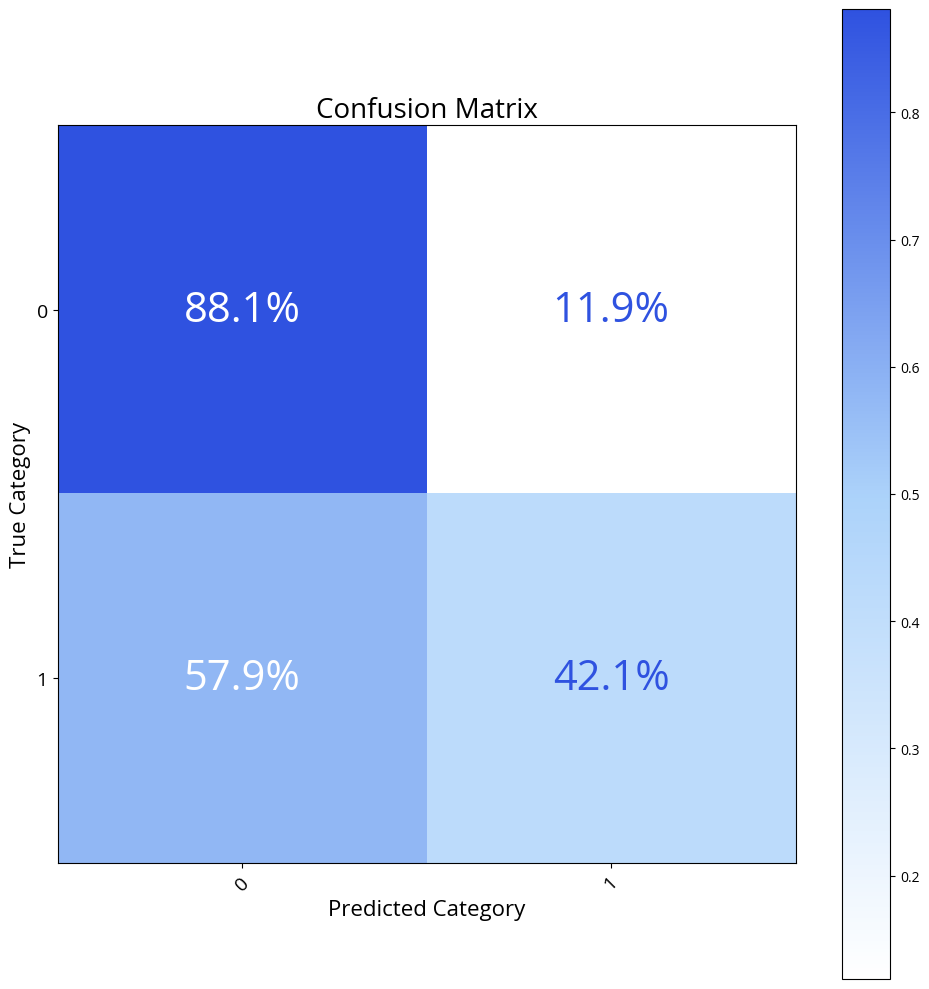

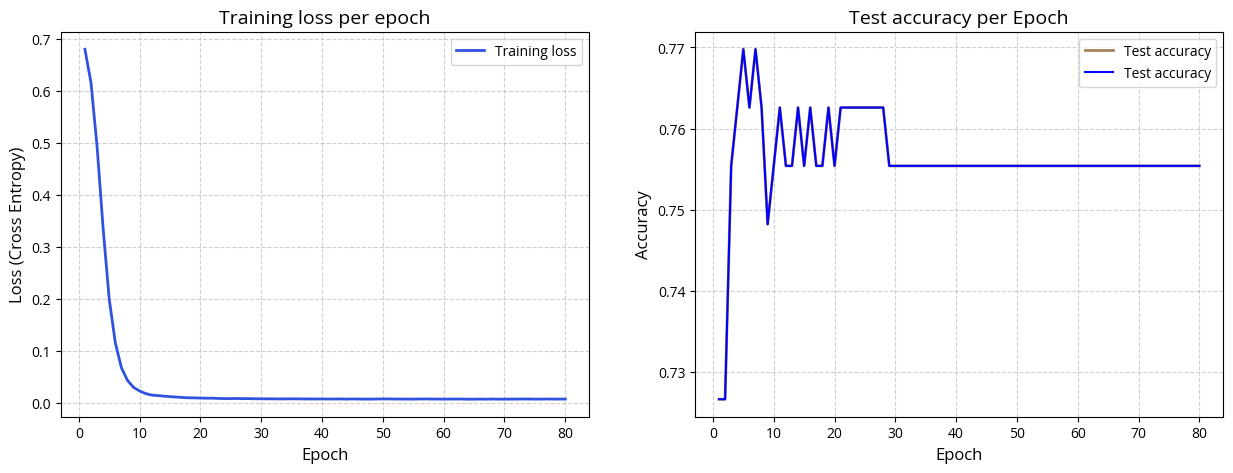

<Figure size 600x400 with 0 Axes>

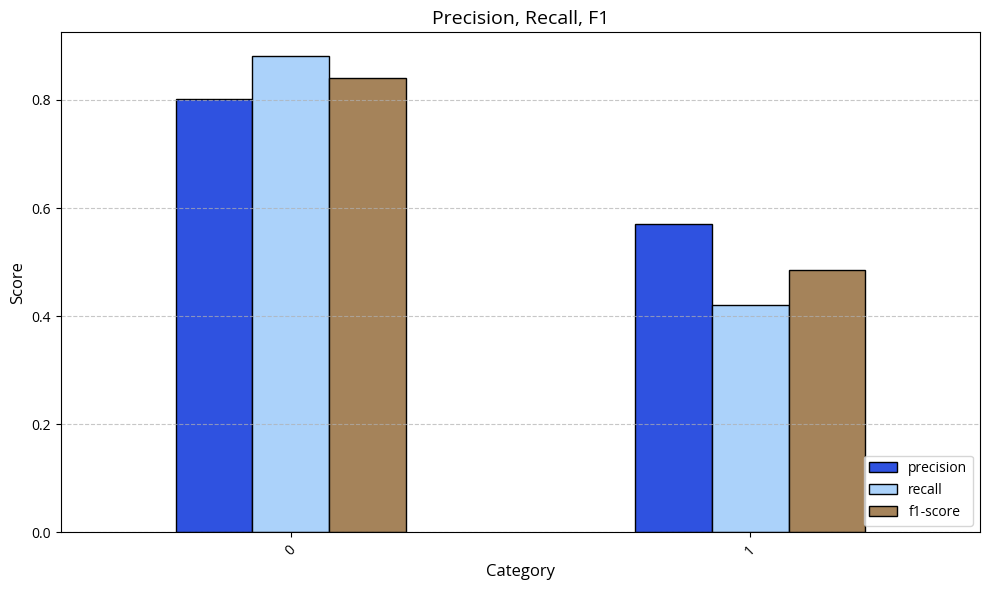

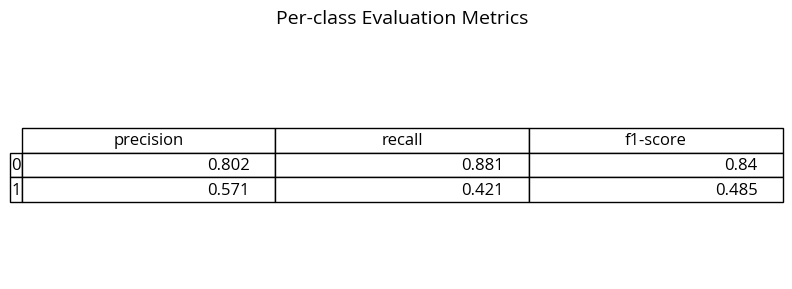

In [5]:
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Simple Feed Forward NN — class weights')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=80,
    lr=1e-3,
    class_weights=True,
    use_scheduler=True
)
print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Deep Feed Forward NN — class weights
Input dimension for NN: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.8404    0.7822    0.8103       101
           1     0.5111    0.6053    0.5542        38

    accuracy                         0.7338       139
   macro avg     0.6758    0.6937    0.6822       139
weighted avg     0.7504    0.7338    0.7403       139



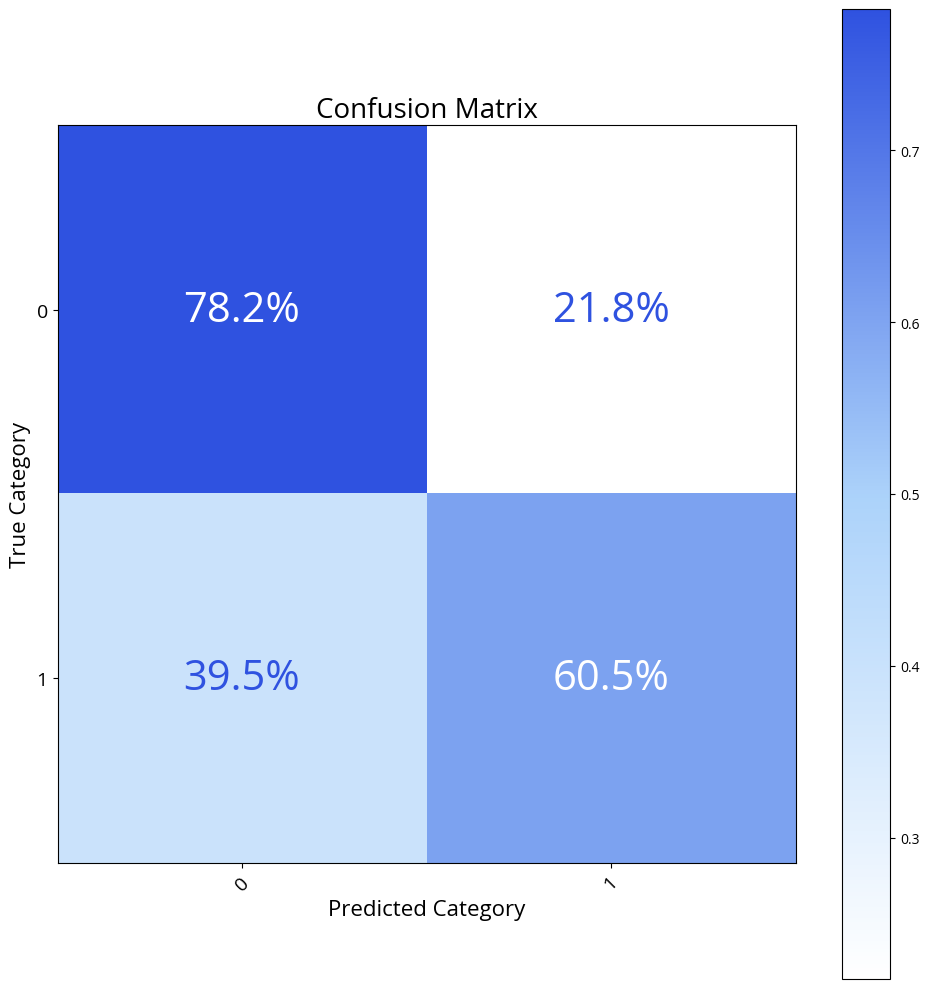

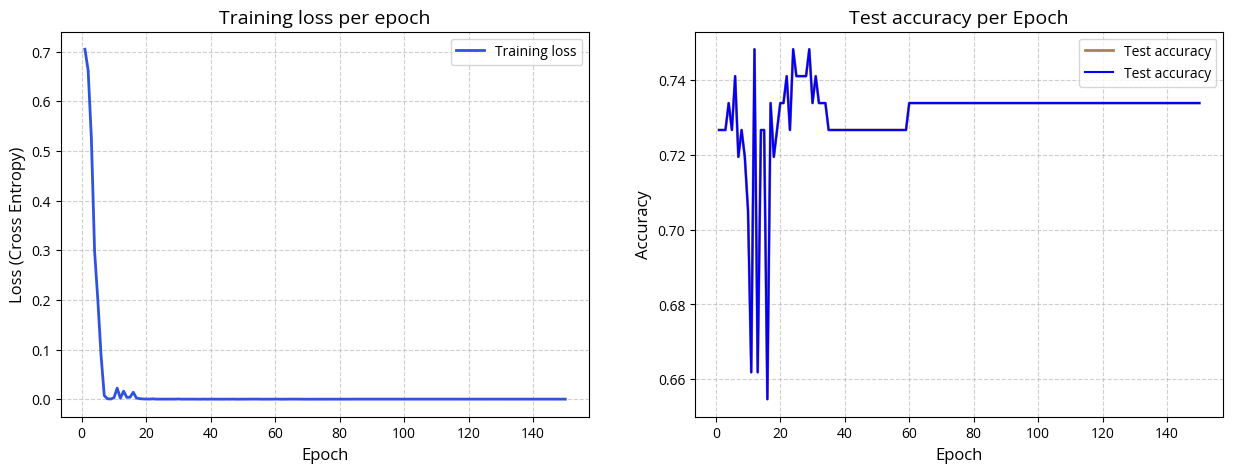

<Figure size 600x400 with 0 Axes>

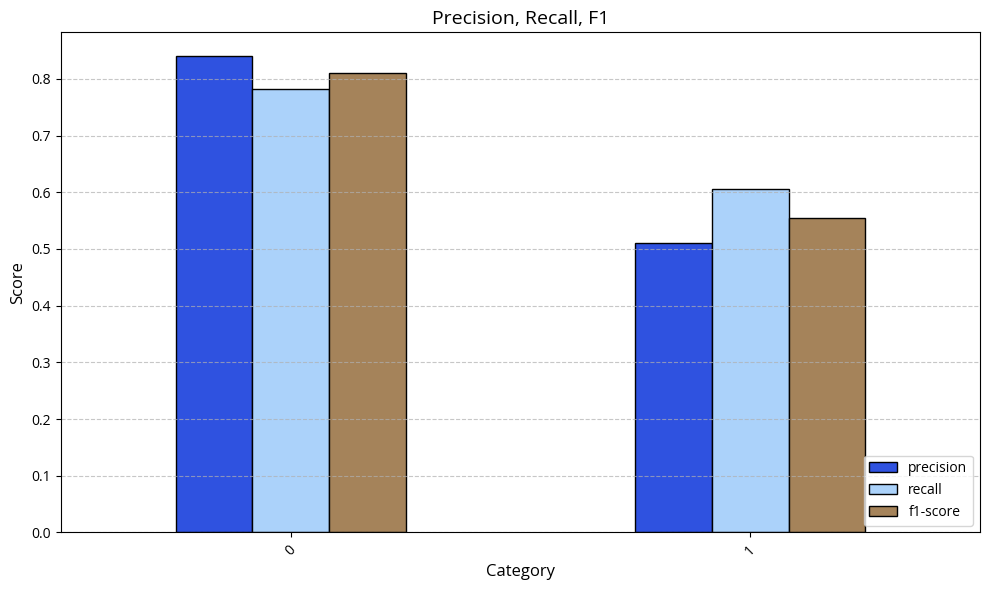

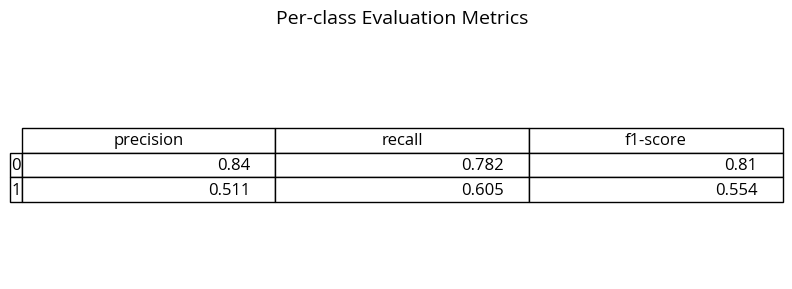

In [11]:
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Deep Feed Forward NN — class weights')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=1e-3,
    class_weights=True,
    use_scheduler=True
)

print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Simple Feed Forward NN — weighted sampler
Class counts: [404 151]
Sample weights per class: [0.00247525 0.00662252]

Classification Report:
              precision    recall  f1-score   support

           0     0.8387    0.7723    0.8041       101
           1     0.5000    0.6053    0.5476        38

    accuracy                         0.7266       139
   macro avg     0.6694    0.6888    0.6759       139
weighted avg     0.7461    0.7266    0.7340       139



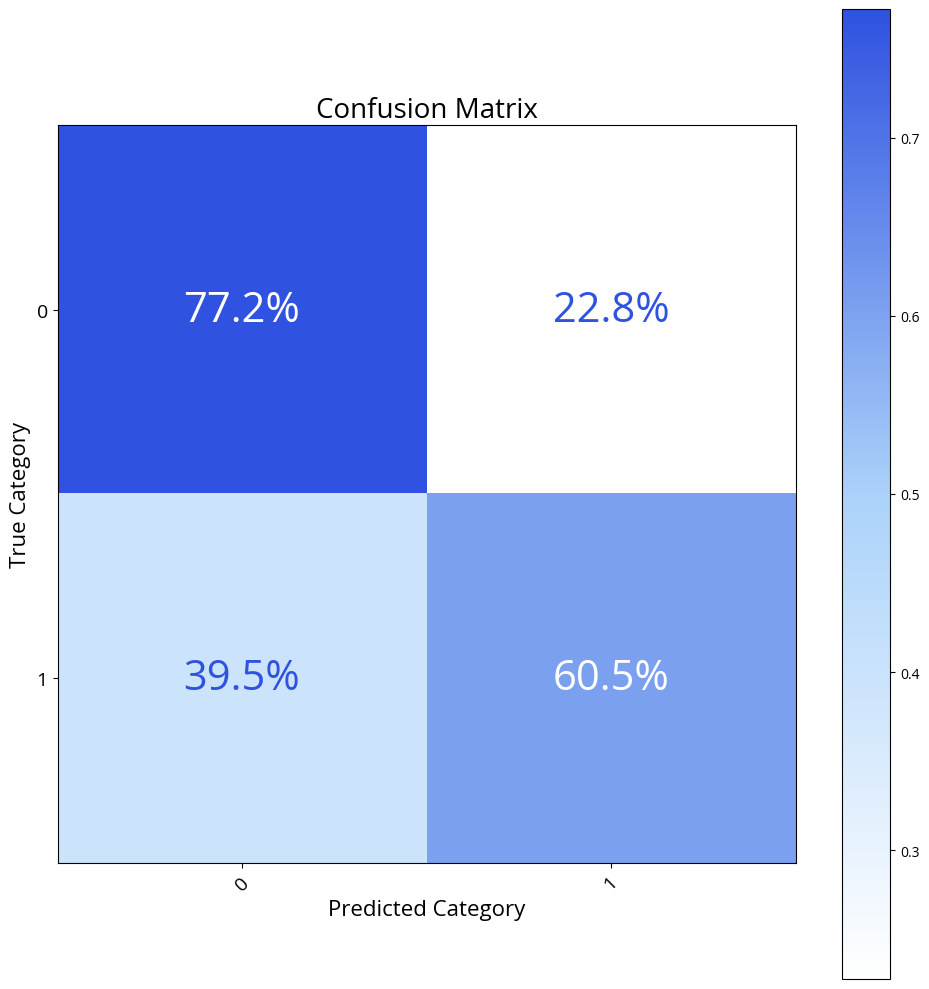

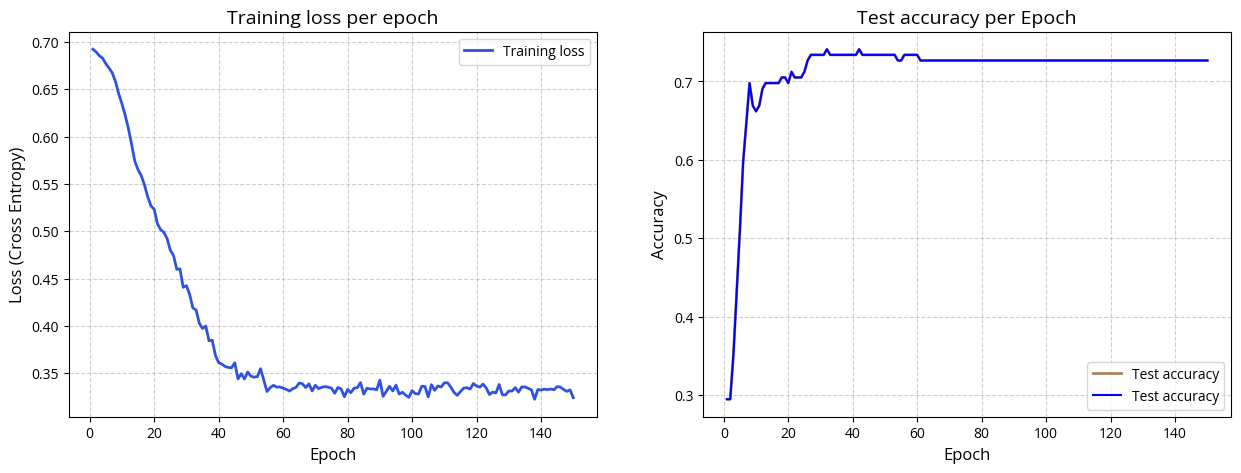

<Figure size 600x400 with 0 Axes>

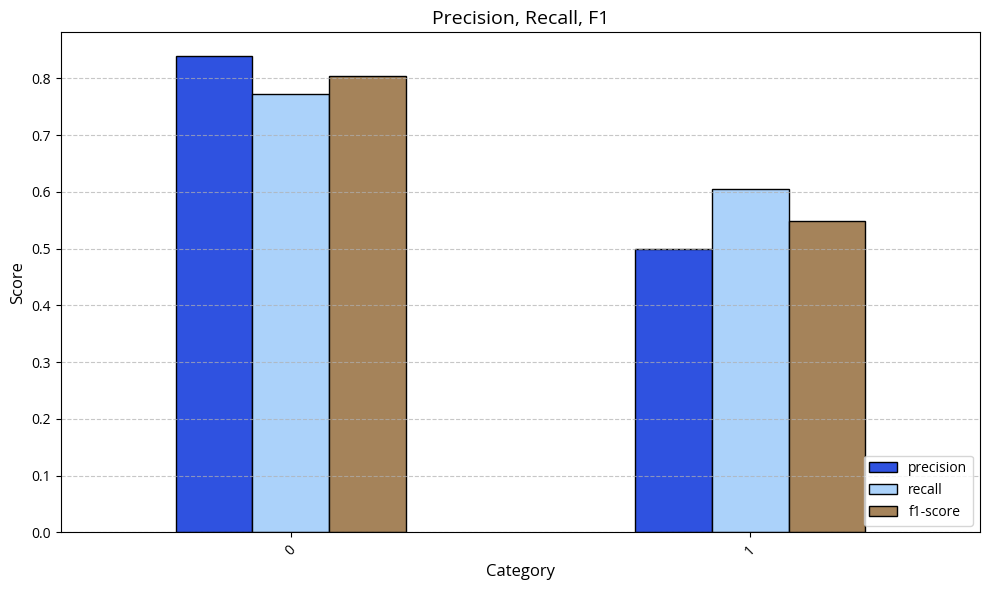

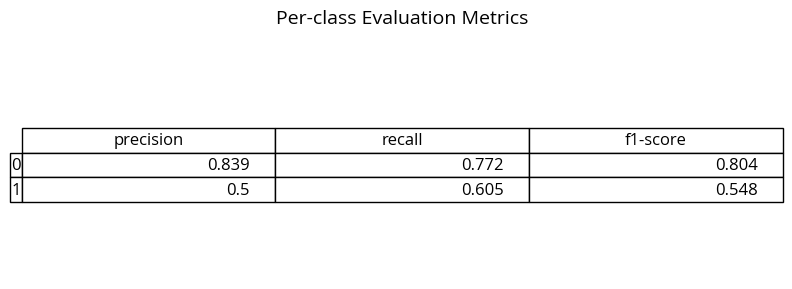

In [7]:
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Simple Feed Forward NN — weighted sampler')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=150,
    lr=8e-5,
    sampler='weighted',
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Deep Feed Forward NN — weighted sampler
Class counts: [404 151]
Sample weights per class: [0.00247525 0.00662252]

Classification Report:
              precision    recall  f1-score   support

           0     0.9000    0.6238    0.7368       101
           1     0.4493    0.8158    0.5794        38

    accuracy                         0.6763       139
   macro avg     0.6746    0.7198    0.6581       139
weighted avg     0.7768    0.6763    0.6938       139



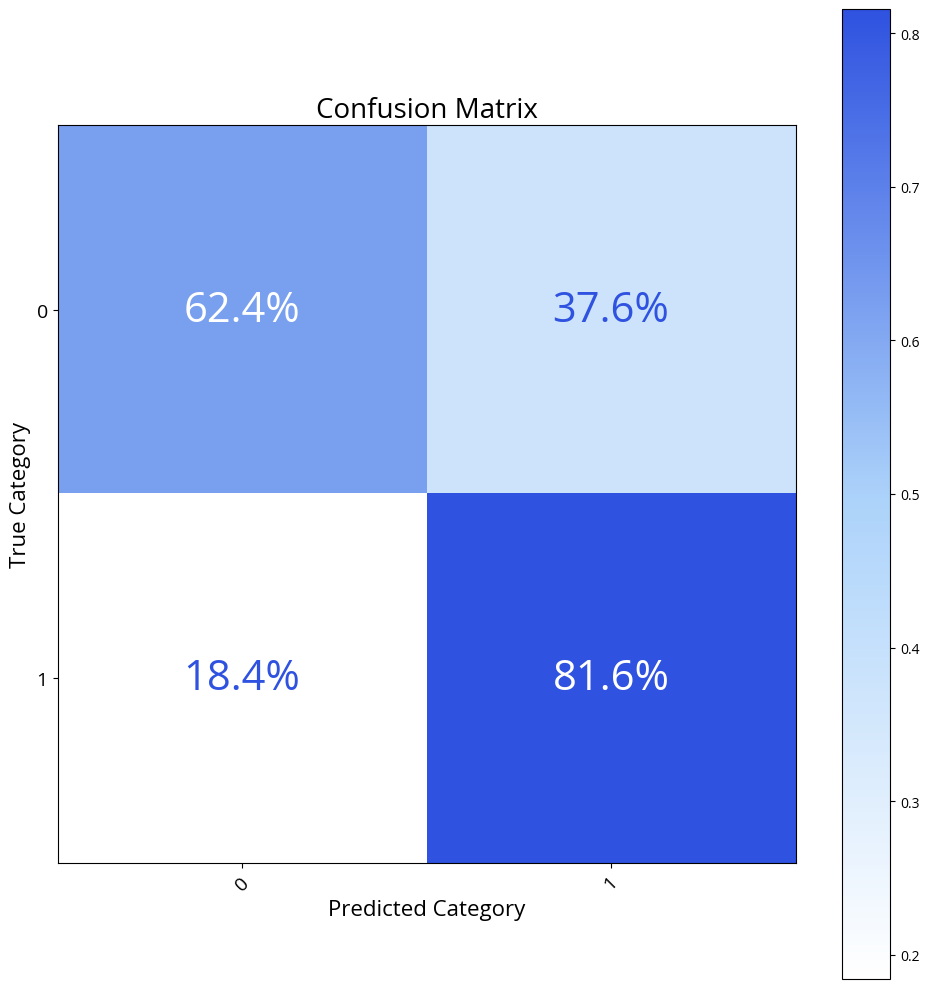

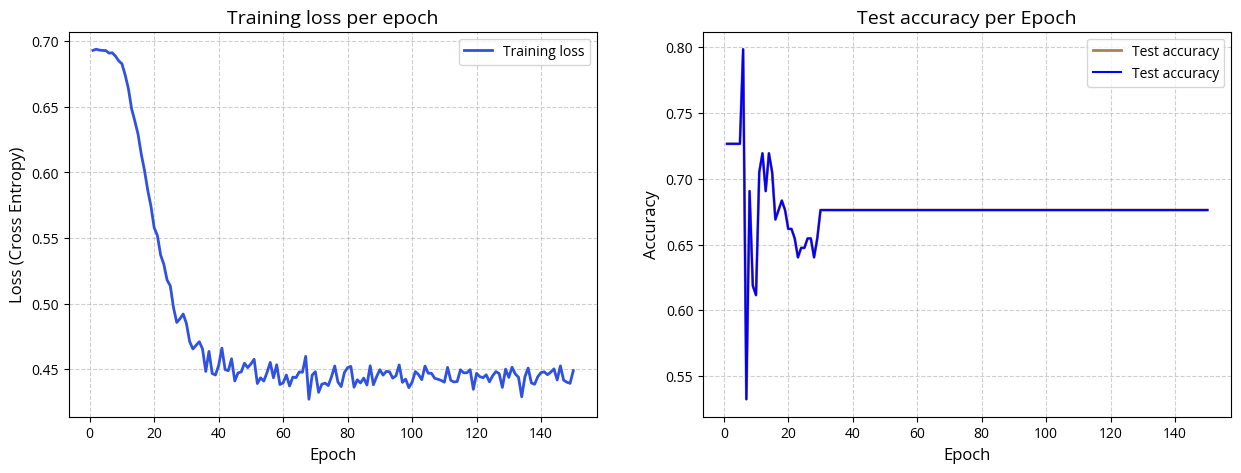

<Figure size 600x400 with 0 Axes>

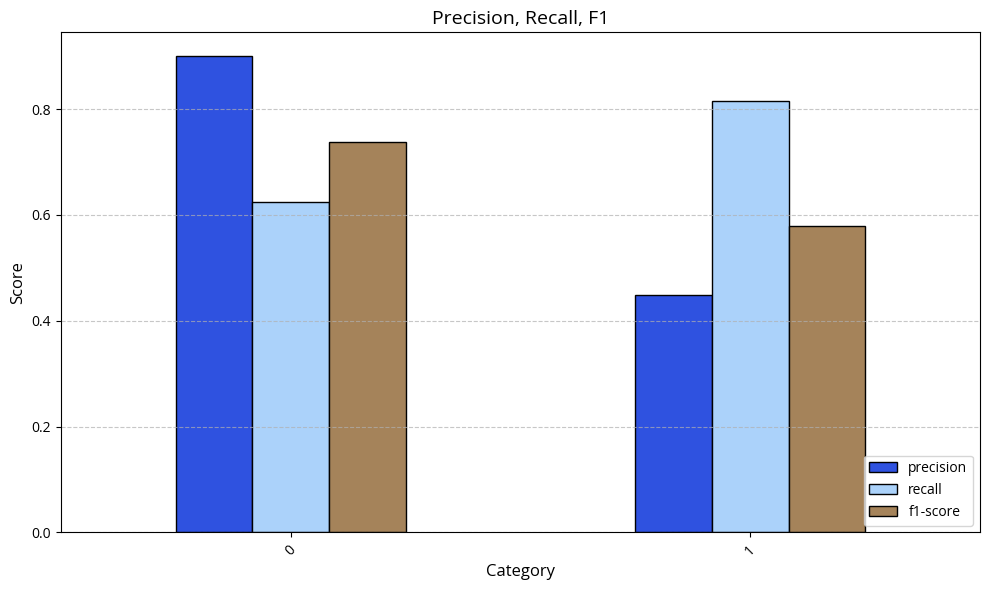

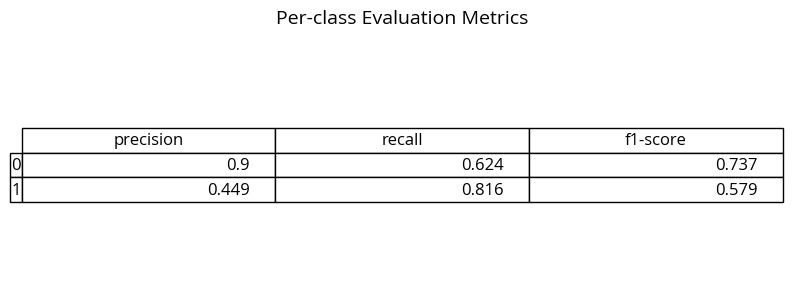

In [8]:
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Deep Feed Forward NN — weighted sampler')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=8e-5,
    sampler='weighted',
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))  # <-- register_buffer keeps it with the model



Classification Report:
              precision    recall  f1-score   support

           0     0.7266    1.0000    0.8417       101
           1     0.0000    0.0000    0.0000        38

    accuracy                         0.7266       139
   macro avg     0.3633    0.5000    0.4208       139
weighted avg     0.5280    0.7266    0.6116       139



/home/xkubanova_126831/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/xkubanova_126831/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/xkubanova_126831/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

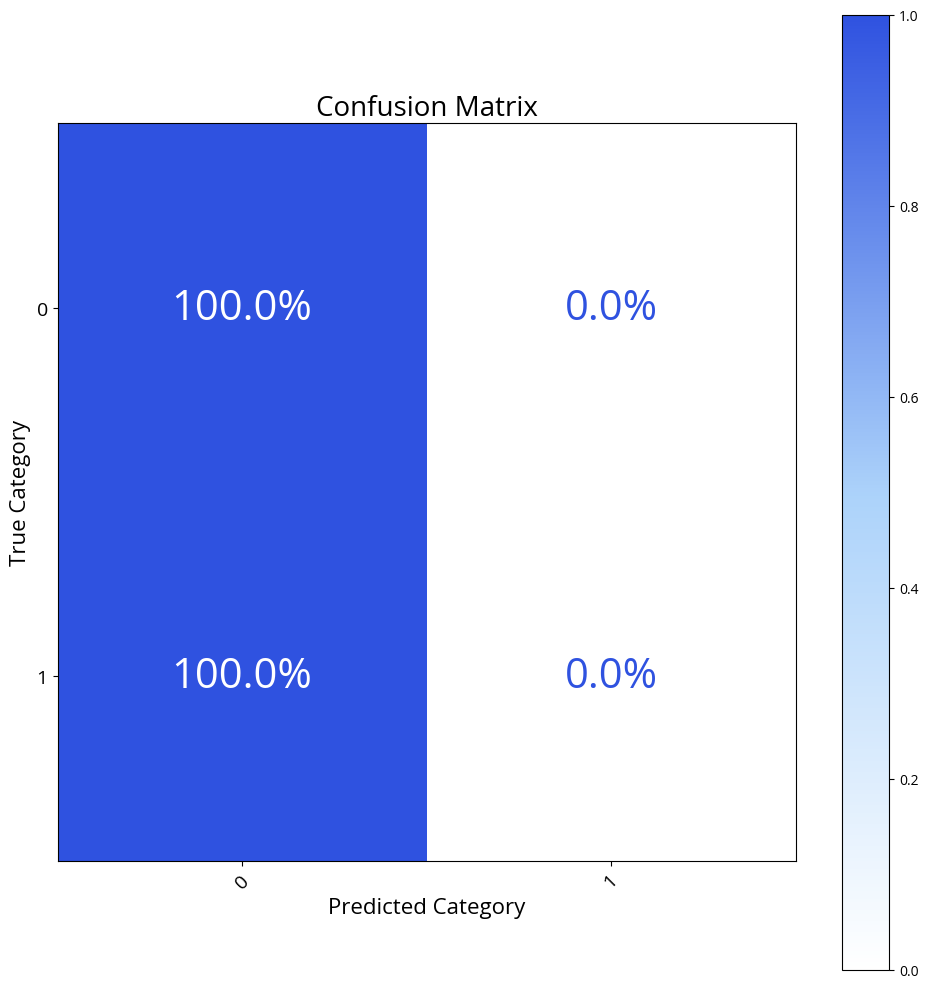

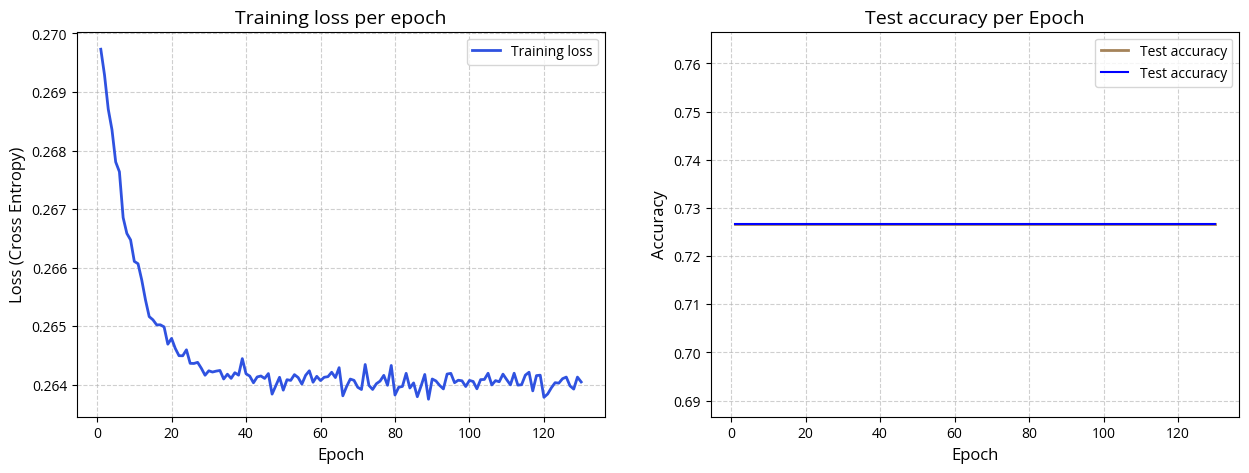

/home/xkubanova_126831/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/xkubanova_126831/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/xkubanova_126831/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

<Figure size 600x400 with 0 Axes>

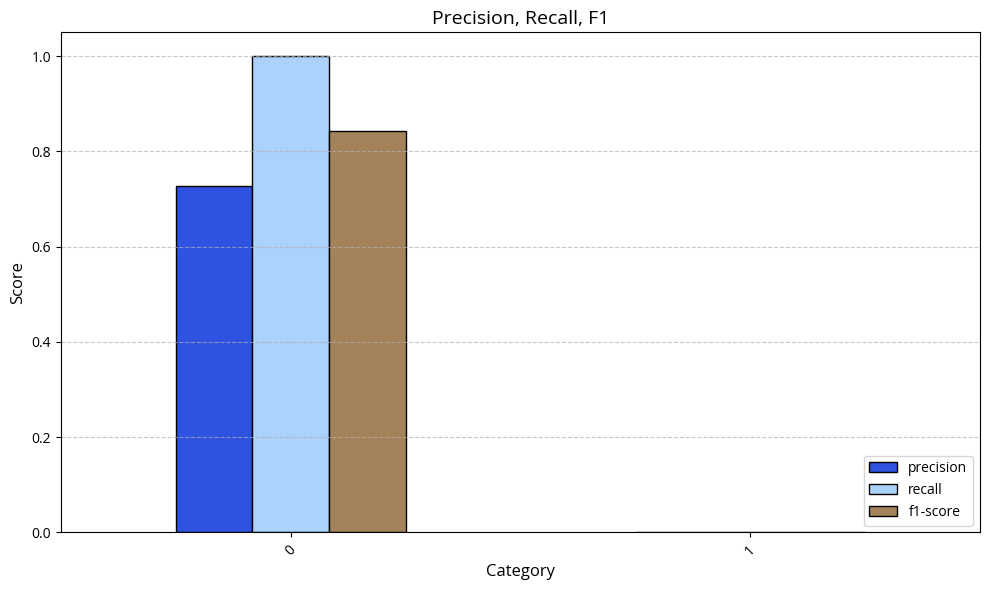

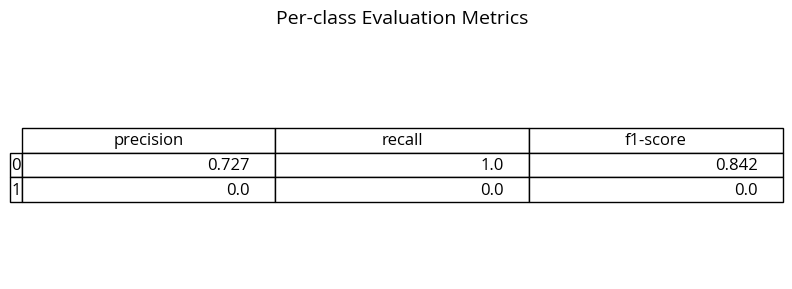

In [9]:
## 8. Simple FF NN — Focal Loss
import torch
from src.ML.train_NN_improved import FocalLoss

X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

alpha = torch.tensor([1.0, 3.0])  # higher weight on minority class (index 1)

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=130,
    lr=1e-5,
    loss_fn=FocalLoss(alpha=alpha, gamma=2),
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))  # <-- register_buffer keeps it with the model



Classification Report:
              precision    recall  f1-score   support

           0     0.8625    0.6832    0.7624       101
           1     0.4576    0.7105    0.5567        38

    accuracy                         0.6906       139
   macro avg     0.6601    0.6968    0.6596       139
weighted avg     0.7518    0.6906    0.7062       139



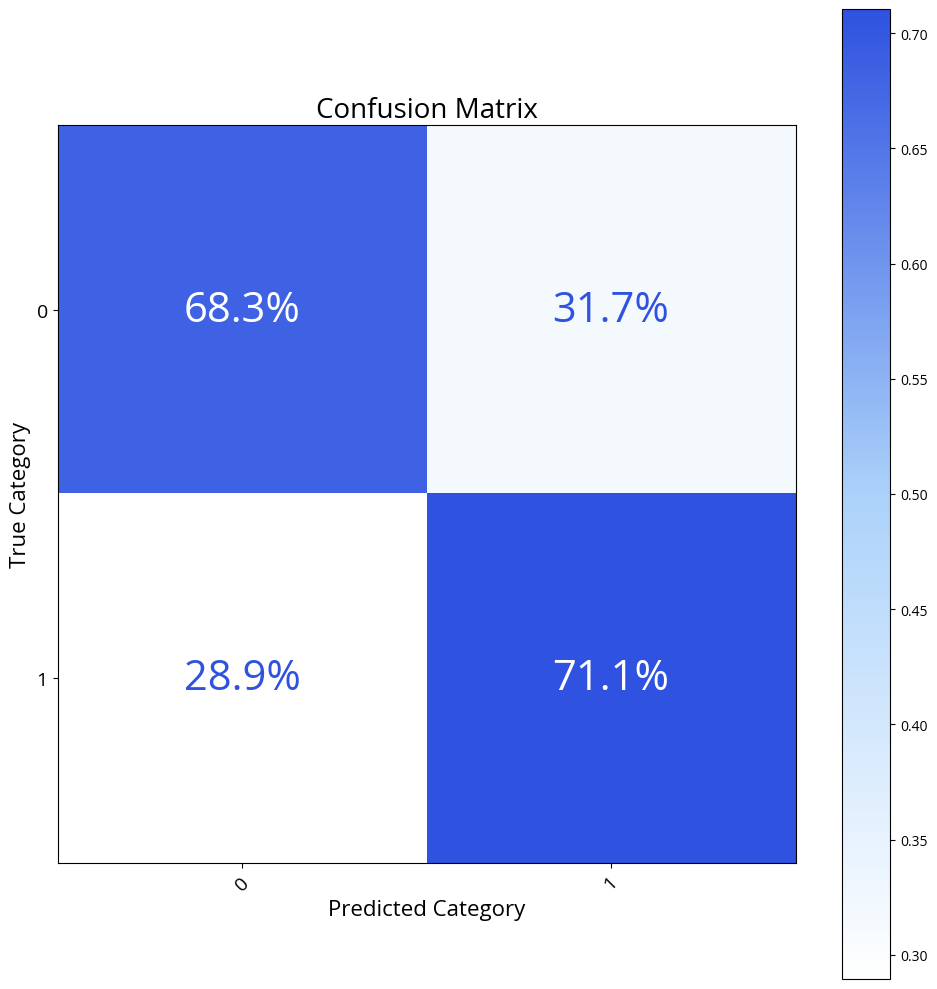

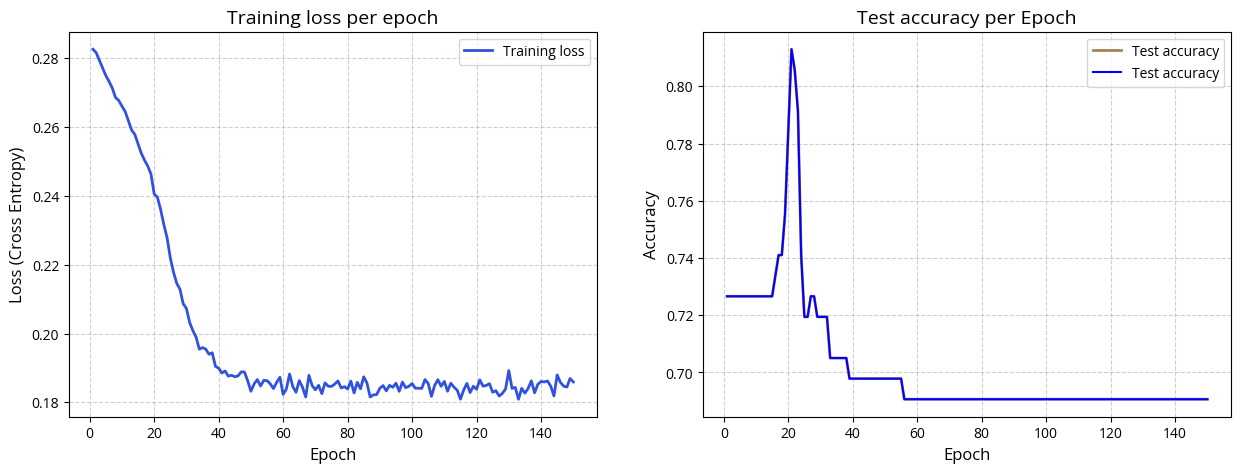

<Figure size 600x400 with 0 Axes>

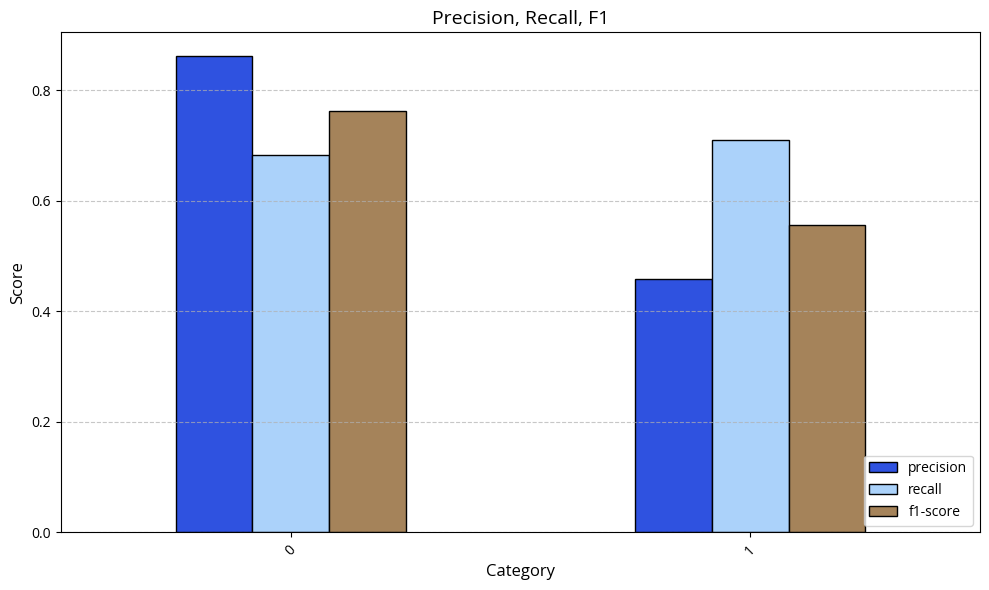

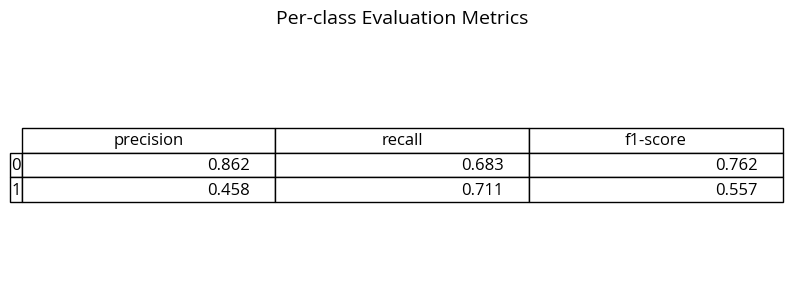

In [10]:
## 9. Deep FF NN — Focal Loss
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

alpha = torch.tensor([1.0, 3.0])

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=1e-4,
    loss_fn=FocalLoss(alpha=alpha, gamma=2),
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)